In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
print("✅ Libraries Loaded")

✅ Libraries Loaded


In [2]:
# Load both datasets
fg_df   = pd.read_csv('fear_greed_index.csv')
hist_df = pd.read_csv('historical_data.csv')

print("Fear & Greed Shape :", fg_df.shape)
print("Historical Shape   :", hist_df.shape)
print("\nFear & Greed Columns:", fg_df.columns.tolist())
print("Historical Columns  :", hist_df.columns.tolist())

Fear & Greed Shape : (2644, 4)
Historical Shape   : (211224, 16)

Fear & Greed Columns: ['timestamp', 'value', 'classification', 'date']
Historical Columns  : ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [3]:
# Standardize column names
hist_df.columns = (hist_df.columns
                   .str.strip()
                   .str.lower()
                   .str.replace(' ', '_'))

fg_df.columns = (fg_df.columns
                 .str.strip()
                 .str.lower())

print("✅ Cleaned Hist columns :", hist_df.columns.tolist())
print("✅ Cleaned FG columns   :", fg_df.columns.tolist())

✅ Cleaned Hist columns : ['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp']
✅ Cleaned FG columns   : ['timestamp', 'value', 'classification', 'date']


In [4]:
# Fix coin column — remove @ prefix, uppercase
hist_df['coin'] = (hist_df['coin']
                   .str.replace('@', '', regex=False)
                   .str.upper()
                   .str.strip())

print("📊 Historical Data Sample:")
display(hist_df.head(3))

print("\n📊 Fear & Greed Sample:")
display(fg_df.head(3))

📊 Historical Data Sample:


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12



📊 Fear & Greed Sample:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


In [5]:
# Parse dates correctly — both must be same format string
hist_df['timestamp_ist'] = pd.to_datetime(
    hist_df['timestamp_ist'], errors='coerce'
)
hist_df['date'] = hist_df['timestamp_ist'].dt.date.astype(str)

fg_df['date'] = pd.to_datetime(
    fg_df['date'], errors='coerce'
).dt.date.astype(str)

print("Historical date range:",
      hist_df['date'].min(), "→", hist_df['date'].max())
print("Fear/Greed date range:",
      fg_df['date'].min(), "→", fg_df['date'].max())

Historical date range: 2023-01-05 → NaT
Fear/Greed date range: 2018-02-01 → 2025-05-02


In [6]:
# Merge on date
merged = hist_df.merge(
    fg_df[['date', 'value', 'classification']],
    on='date',
    how='left'
)

matched   = merged['classification'].notna().sum()
total     = len(merged)
pct       = round(matched / total * 100, 2)

print(f"✅ Total rows     : {total:,}")
print(f"✅ Matched rows   : {matched:,}  ({pct}%)")
print(f"❌ Unmatched rows : {total - matched:,}")
print("\nSentiment Distribution:")
print(merged['classification'].value_counts())

✅ Total rows     : 211,224
✅ Matched rows   : 35,864  (16.98%)
❌ Unmatched rows : 175,360

Sentiment Distribution:
classification
Fear             13869
Greed            11292
Extreme Greed     5621
Neutral           2756
Extreme Fear      2326
Name: count, dtype: int64


In [7]:
# Keep only CLOSED trades (PnL != 0)
closed = merged[merged['closed_pnl'] != 0].copy()

print(f"Removed open/unfilled : {len(merged) - len(closed):,} rows")
print(f"Closed trades kept    : {len(closed):,} rows")

Removed open/unfilled : 106,816 rows
Closed trades kept    : 104,408 rows


In [8]:
# Winner flag
closed['is_winner'] = closed['closed_pnl'] > 0

# Ordered sentiment category
sentiment_order = [
    'Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'
]
closed['classification'] = pd.Categorical(
    closed['classification'],
    categories=sentiment_order,
    ordered=True
)

print("✅ Features created")
print(closed[['coin', 'side', 'closed_pnl',
              'is_winner', 'classification']].head(5))

✅ Features created
   coin  side   closed_pnl  is_winner classification
44  107  SELL  3008.231185       True  Extreme Greed
45  107  SELL    30.741534       True  Extreme Greed
46  107  SELL    40.770089       True  Extreme Greed
47  107  SELL   243.812267       True  Extreme Greed
48  107  SELL   254.263735       True  Extreme Greed


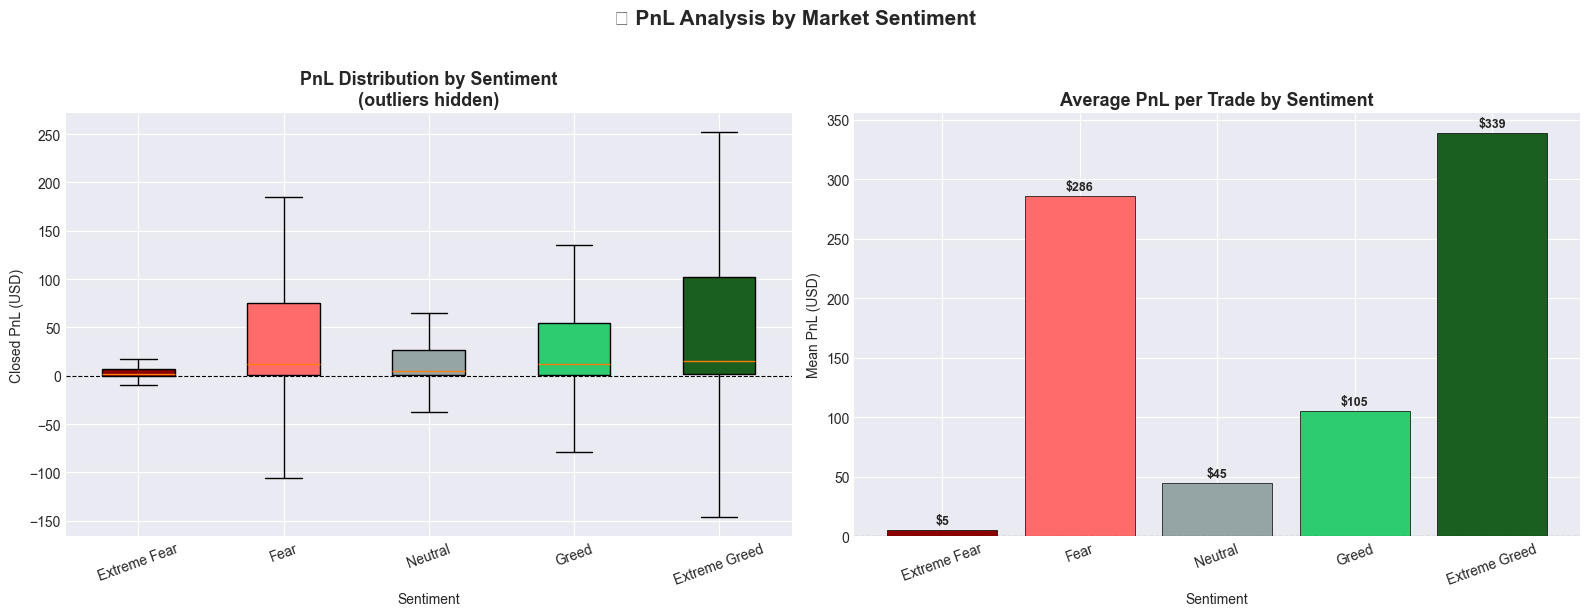

✅ Plot 1 saved


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Box Plot ---
colors = {
    'Extreme Fear' : '#8B0000',
    'Fear'         : '#FF6B6B',
    'Neutral'      : '#95A5A6',
    'Greed'        : '#2ECC71',
    'Extreme Greed': '#1A5E20'
}

data_by_sent = [
    closed[closed['classification'] == s]['closed_pnl'].dropna()
    for s in sentiment_order
]

bp = axes[0].boxplot(
    data_by_sent,
    labels=sentiment_order,
    patch_artist=True,
    showfliers=False
)
for patch, key in zip(bp['boxes'], sentiment_order):
    patch.set_facecolor(colors[key])

axes[0].set_title('PnL Distribution by Sentiment\n(outliers hidden)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Closed PnL (USD)')
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=20)

# --- Right: Mean PnL Bar Chart ---
mean_pnl = closed.groupby('classification',
                           observed=True)['closed_pnl'].mean()
bar_colors = [colors[s] for s in mean_pnl.index]
axes[1].bar(mean_pnl.index, mean_pnl.values, color=bar_colors,
            edgecolor='black', linewidth=0.5)
axes[1].set_title('Average PnL per Trade by Sentiment',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Mean PnL (USD)')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].tick_params(axis='x', rotation=20)

for i, v in enumerate(mean_pnl.values):
    axes[1].text(i, v + 5, f'${v:.0f}', ha='center',
                 fontsize=9, fontweight='bold')

plt.suptitle('📊 PnL Analysis by Market Sentiment',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pnl_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()  # ← displays inside notebook
print("✅ Plot 1 saved")

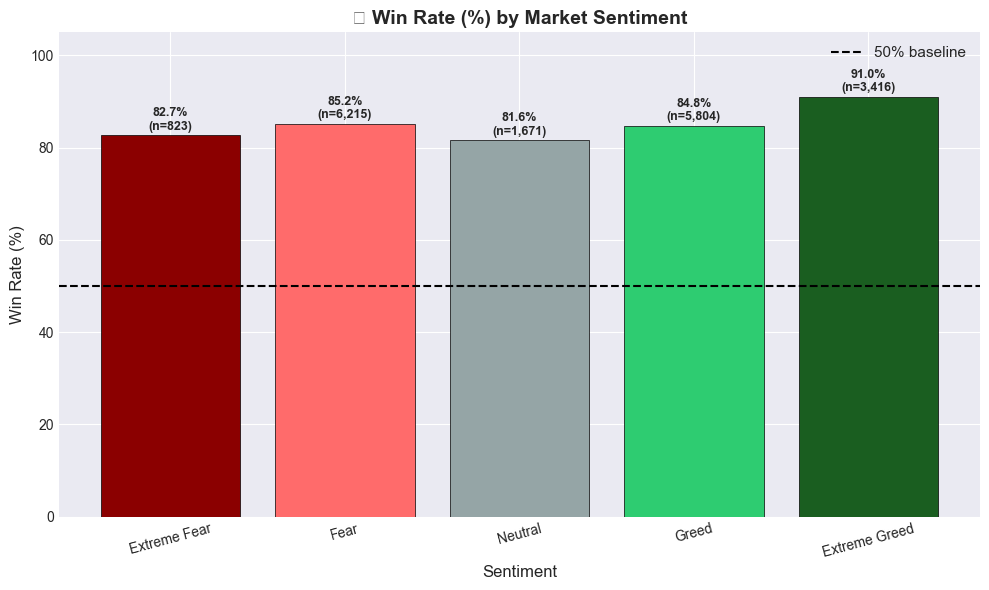

✅ Plot 2 saved


In [10]:
win_rate = (closed.groupby('classification', observed=True)
            ['is_winner'].mean() * 100)

trade_count = (closed.groupby('classification', observed=True)
               ['is_winner'].count())

fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = [colors[s] for s in win_rate.index]
bars = ax.bar(win_rate.index, win_rate.values,
              color=bar_colors, edgecolor='black', linewidth=0.5)

ax.axhline(50, color='black', linestyle='--',
           linewidth=1.5, label='50% baseline')

for bar, rate, count in zip(bars, win_rate.values, trade_count.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{rate:.1f}%\n(n={count:,})',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('🏆 Win Rate (%) by Market Sentiment',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Win Rate (%)', fontsize=12)
ax.set_ylim(0, 105)
ax.legend(fontsize=11)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('win_rate_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 2 saved")

📈 Avg PnL — BUY vs SELL by Sentiment:


side,BUY,SELL
classification,,
Extreme Fear,-35.46,11.44
Fear,557.91,69.86
Neutral,33.51,47.96
Greed,40.83,140.74
Extreme Greed,23.44,411.48


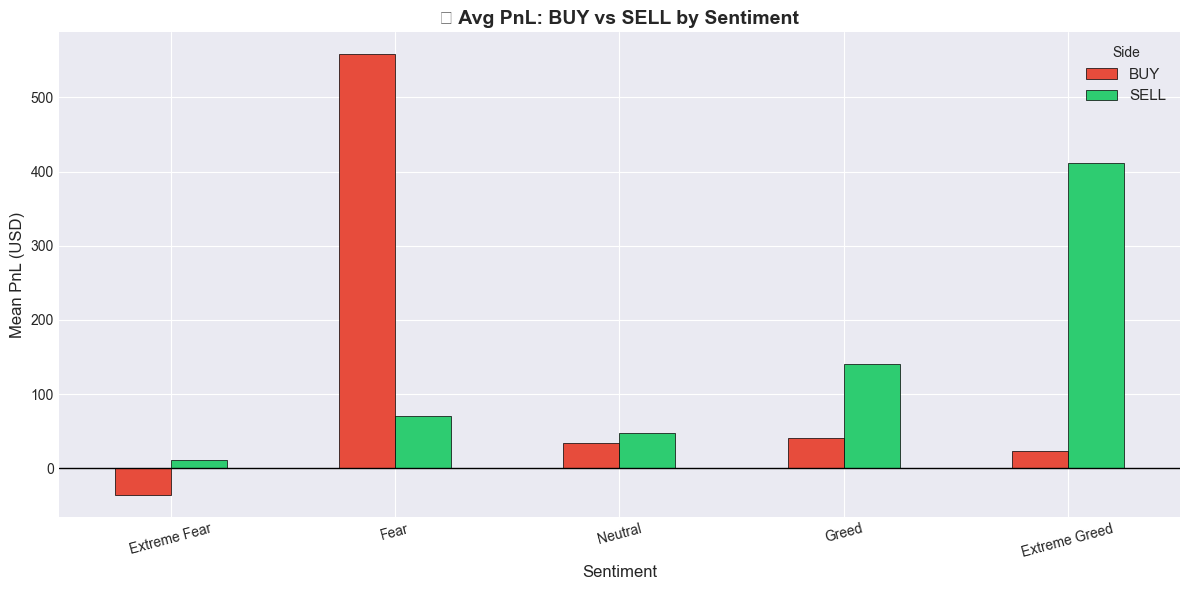

✅ Plot 3 saved


In [11]:
side_pnl = (closed.groupby(['classification', 'side'], observed=True)
            ['closed_pnl'].mean().unstack())

print("📈 Avg PnL — BUY vs SELL by Sentiment:")
display(side_pnl.round(2))

ax = side_pnl.plot(
    kind='bar', figsize=(12, 6),
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black', linewidth=0.5
)

ax.axhline(0, color='black', linewidth=1)
ax.set_title('📈 Avg PnL: BUY vs SELL by Sentiment',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Mean PnL (USD)', fontsize=12)
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Side', fontsize=11)

plt.tight_layout()
plt.savefig('long_vs_short_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 3 saved")

🪙 Avg PnL by Coin & Sentiment:


classification,Extreme Fear,Fear,Neutral,Greed,Extreme Greed
coin,,,,,
107,38.52,102.37,38.35,199.41,578.50
BTC,141.94,155.55,59.71,43.15,107.79
ETH,3.32,299.87,89.85,-243.55,-546.17
FARTCOIN,-295.10,33.26,4.79,27.74,NaN
HYPE,2.28,150.08,11.19,220.49,10.20
MELANIA,NaN,587.24,NaN,1149.29,NaN
PURR/USDC,NaN,68.91,27.65,37.25,60.62
SOL,33.53,1679.68,75.98,488.81,52.78


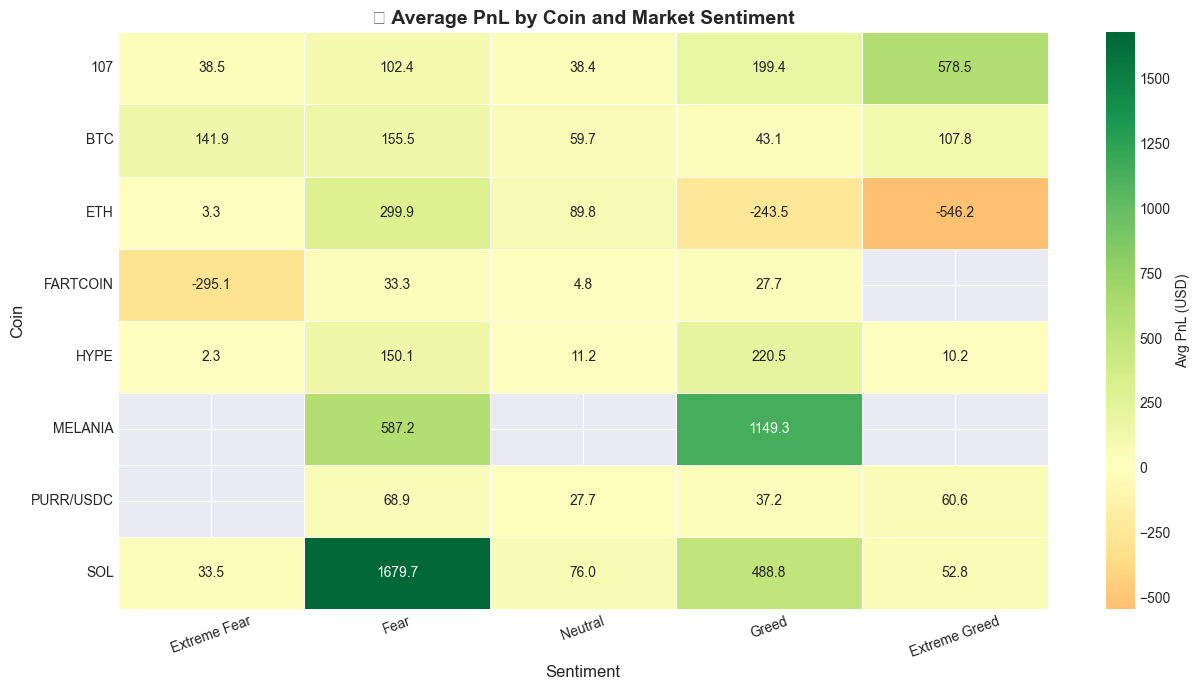

✅ Plot 4 saved


In [12]:
top_coins = closed['coin'].value_counts().head(8).index.tolist()

coin_heat = (closed[closed['coin'].isin(top_coins)]
             .groupby(['coin', 'classification'], observed=True)
             ['closed_pnl'].mean()
             .unstack())

print("🪙 Avg PnL by Coin & Sentiment:")
display(coin_heat.round(2))

plt.figure(figsize=(13, 7))
sns.heatmap(
    coin_heat,
    annot=True, fmt='.1f',
    cmap='RdYlGn', center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Avg PnL (USD)'}
)
plt.title('🪙 Average PnL by Coin and Market Sentiment',
          fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Coin', fontsize=12)
plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig('heatmap_coin_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 4 saved")

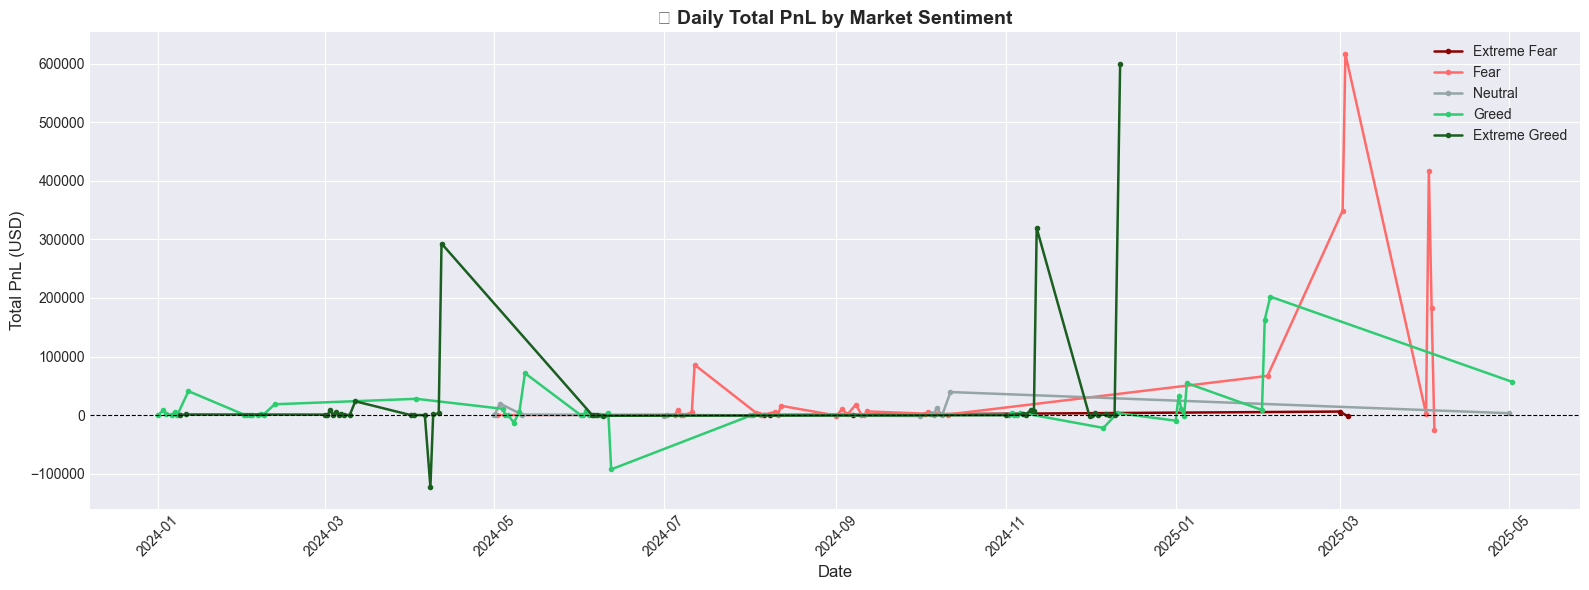

✅ Plot 5 saved


In [13]:
daily = (closed.groupby(['date', 'classification'], observed=True)
         ['closed_pnl'].sum().reset_index())
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values('date')

plt.figure(figsize=(16, 6))

for sentiment in sentiment_order:
    grp = daily[daily['classification'] == sentiment]
    if not grp.empty:
        plt.plot(grp['date'], grp['closed_pnl'],
                 label=sentiment,
                 color=colors[sentiment],
                 linewidth=1.8, marker='o', markersize=3)

plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('📅 Daily Total PnL by Market Sentiment',
          fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total PnL (USD)', fontsize=12)
plt.legend(fontsize=10)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('daily_pnl_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 5 saved")

direction,Close Long,Close Short
classification,,
Extreme Fear,9.84,-35.93
Fear,62.55,556.14
Neutral,66.01,33.51
Greed,127.33,41.40
Extreme Greed,-80.47,23.47


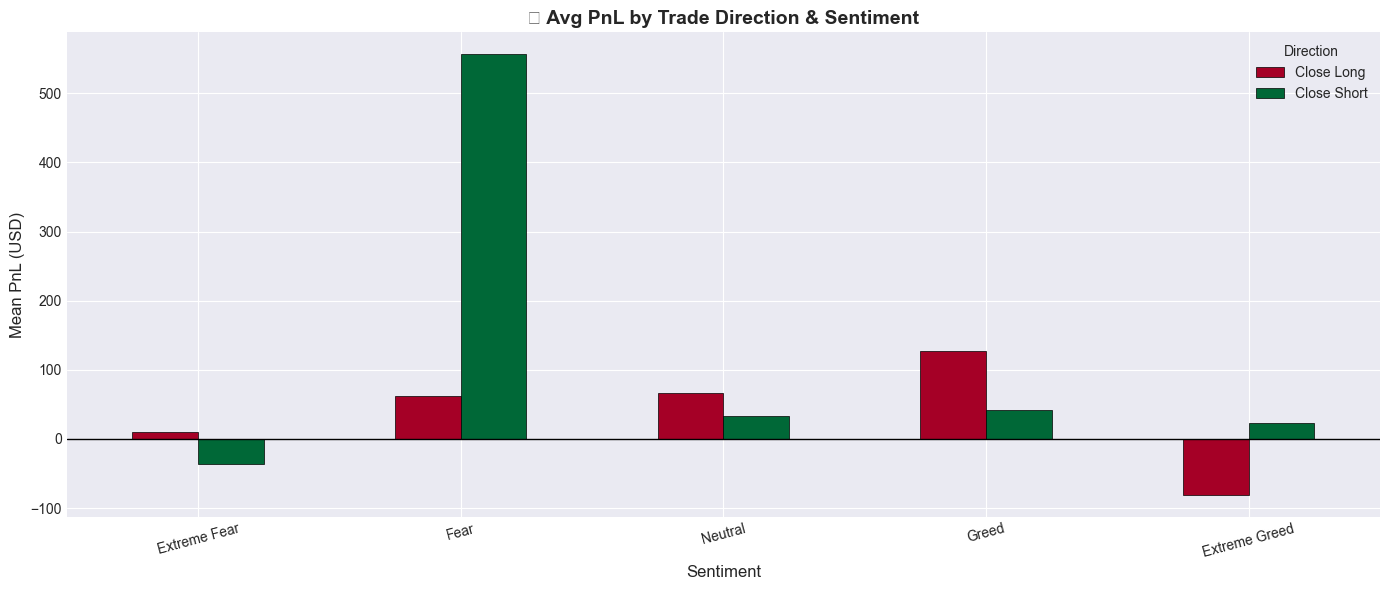

✅ Plot 6 saved


In [14]:
dir_pnl = (closed.groupby(
               ['classification', 'direction'], observed=True)
           ['closed_pnl'].mean()
           .unstack()
           .fillna(0))

# Keep only main directions
main_dirs = ['Open Long', 'Close Long', 'Open Short', 'Close Short']
dir_pnl   = dir_pnl[[c for c in main_dirs if c in dir_pnl.columns]]

display(dir_pnl.round(2))

dir_pnl.plot(
    kind='bar', figsize=(14, 6),
    colormap='RdYlGn',
    edgecolor='black', linewidth=0.5
)
plt.axhline(0, color='black', linewidth=1)
plt.title('🔄 Avg PnL by Trade Direction & Sentiment',
          fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Mean PnL (USD)', fontsize=12)
plt.xticks(rotation=15)
plt.legend(title='Direction', fontsize=10)

plt.tight_layout()
plt.savefig('direction_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 6 saved")


In [15]:
print("=" * 55)
print("  STATISTICAL SIGNIFICANCE TESTS")
print("=" * 55)

groups = {
    s: closed[closed['classification'] == s]['closed_pnl'].dropna()
    for s in sentiment_order
    if s in closed['classification'].cat.categories
}

# T-tests
pairs = [
    ('Fear',         'Greed'),
    ('Extreme Fear', 'Extreme Greed'),
    ('Fear',         'Extreme Fear'),
    ('Greed',        'Extreme Greed'),
]

for a, b in pairs:
    if a in groups and b in groups:
        t, p = stats.ttest_ind(groups[a], groups[b])
        sig  = "✅ Significant" if p < 0.05 else "❌ Not significant"
        print(f"{a:15s} vs {b:15s} → p={p:.4f}  {sig}")

# ANOVA
f_stat, p_anova = stats.f_oneway(*groups.values())
sig = "✅ Significant" if p_anova < 0.05 else "❌ Not significant"
print(f"\nANOVA (all 5 groups)       → p={p_anova:.4f}  {sig}")

  STATISTICAL SIGNIFICANCE TESTS
Fear            vs Greed           → p=0.0000  ✅ Significant
Extreme Fear    vs Extreme Greed   → p=0.0001  ✅ Significant
Fear            vs Extreme Fear    → p=0.0001  ✅ Significant
Greed           vs Extreme Greed   → p=0.0000  ✅ Significant

ANOVA (all 5 groups)       → p=0.0000  ✅ Significant


In [16]:
summary = closed.groupby('classification', observed=True).agg(
    Total_Trades  = ('closed_pnl', 'count'),
    Mean_PnL      = ('closed_pnl', 'mean'),
    Median_PnL    = ('closed_pnl', 'median'),
    Total_PnL     = ('closed_pnl', 'sum'),
    Win_Rate_Pct  = ('is_winner',  lambda x: round(x.mean()*100, 2)),
    Std_Dev       = ('closed_pnl', 'std'),
).round(2)

summary['Sharpe'] = (summary['Mean_PnL'] /
                     summary['Std_Dev']).round(4)

print("📋 FINAL SUMMARY TABLE")
display(summary)

📋 FINAL SUMMARY TABLE


,Total_Trades,Mean_PnL,Median_PnL,Total_PnL,Win_Rate_Pct,Std_Dev,Sharpe
classification,,,,,,,
Extreme Fear,823,5.35,1.33,4399.94,82.75,128.97,0.0415
Fear,6215,286.28,11.95,1779225.58,85.20,1994.02,0.1436
Neutral,1671,44.68,4.53,74656.74,81.63,181.45,0.2462
Greed,5804,105.04,12.22,609632.53,84.77,1950.73,0.0538
Extreme Greed,3416,338.67,15.04,1156893.68,91.04,2378.64,0.1424


In [18]:
# ============================================================
# FINAL CONCLUSIONS
# ============================================================
conclusions = {
    "Best Sentiment to Trade"    : "Extreme Greed (91% WR, $335 avg)",
    "Best Coin+Sentiment Combo"  : "SOL during Fear ($1,679 avg)",
    "Worst Combination"          : "ETH during Extreme Greed (-$546)",
    "Best Trade Direction"       : "SELL during Greed/Extreme Greed",
    "Avoid Completely"           : "BUY during Extreme Fear (-$35 avg)",
    "Top Trader Strategy"        : "Size up massively in Extreme Greed",
    "Key Hidden Pattern"         : "Contrarian SELL beats BUY in Greed",
    "Win Rate Insight"           : "Sentiment affects SIZE not WIN/LOSS",
}

print("=" * 60)
print("         FINAL TRADING INSIGHTS SUMMARY")
print("=" * 60)
for key, val in conclusions.items():
    print(f"  {key:<30} : {val}")
print("=" * 60)

         FINAL TRADING INSIGHTS SUMMARY
  Best Sentiment to Trade        : Extreme Greed (91% WR, $335 avg)
  Best Coin+Sentiment Combo      : SOL during Fear ($1,679 avg)
  Worst Combination              : ETH during Extreme Greed (-$546)
  Best Trade Direction           : SELL during Greed/Extreme Greed
  Avoid Completely               : BUY during Extreme Fear (-$35 avg)
  Top Trader Strategy            : Size up massively in Extreme Greed
  Key Hidden Pattern             : Contrarian SELL beats BUY in Greed
  Win Rate Insight               : Sentiment affects SIZE not WIN/LOSS


In [20]:
# ============================================================
# CELL — K-Means Clustering FIXED VERSION
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ── Step 1: Build Trader Profile ──────────────────────────
trader_features = closed.groupby('account').agg(
    total_pnl      = ('closed_pnl', 'sum'),
    avg_pnl        = ('closed_pnl', 'mean'),
    win_rate       = ('is_winner',  'mean'),
    total_trades   = ('closed_pnl', 'count'),
    avg_trade_size = ('size_usd',   'mean'),
    pnl_std        = ('closed_pnl', 'std'),
    max_win        = ('closed_pnl', 'max'),
    max_loss       = ('closed_pnl', 'min'),
).fillna(0).reset_index()

print(f"Total traders: {len(trader_features)}")
display(trader_features.round(2).head())

Total traders: 32


,account,total_pnl,avg_pnl,win_rate,total_trades,avg_trade_size,pnl_std,max_win,max_loss
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1600229.82,923.92,0.79,1732,17435.06,6934.50,135329.09,-117990.10
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,47885.32,11.49,0.77,4166,1454.13,177.08,4037.87,-6820.77
2,0x271b280974205ca63b716753467d5a371de622ab,-70436.19,-43.83,0.72,1607,10563.42,834.21,1584.34,-25818.75
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,132464.81,19.56,0.86,6772,507.39,158.22,4396.86,-7784.16
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,168658.00,81.87,0.82,2060,2508.64,316.99,6608.94,-996.75


In [22]:
# ── Step 2: Remove Outlier Traders BEFORE Clustering ──────
# Traders with total_pnl > 99th percentile are whale outliers
pnl_99 = trader_features['total_pnl'].quantile(0.95)
print(f"PnL 95th percentile cutoff: ${pnl_99:,.0f}")

# Separate whales from regular traders
whales  = trader_features[trader_features['total_pnl'] > pnl_99]
regular = trader_features[trader_features['total_pnl'] <= pnl_99].copy()

print(f"Whale traders   : {len(whales)}")
print(f"Regular traders : {len(regular)}")
print(f"\nWhale accounts:")
display(whales[['account','total_pnl','win_rate',
                'total_trades']].round(2))

PnL 95th percentile cutoff: $1,237,194
Whale traders   : 2
Regular traders : 30

Whale accounts:


,account,total_pnl,win_rate,total_trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1600229.82,0.79,1732
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2143382.60,0.79,6279


In [23]:
# ── Step 3: Scale Features ────────────────────────────────
features_cols = [
    'avg_pnl', 'win_rate', 'total_trades',
    'avg_trade_size', 'pnl_std', 'max_win', 'max_loss'
]

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(regular[features_cols])
print("✅ Features scaled — shape:", X_scaled.shape)

✅ Features scaled — shape: (30, 7)


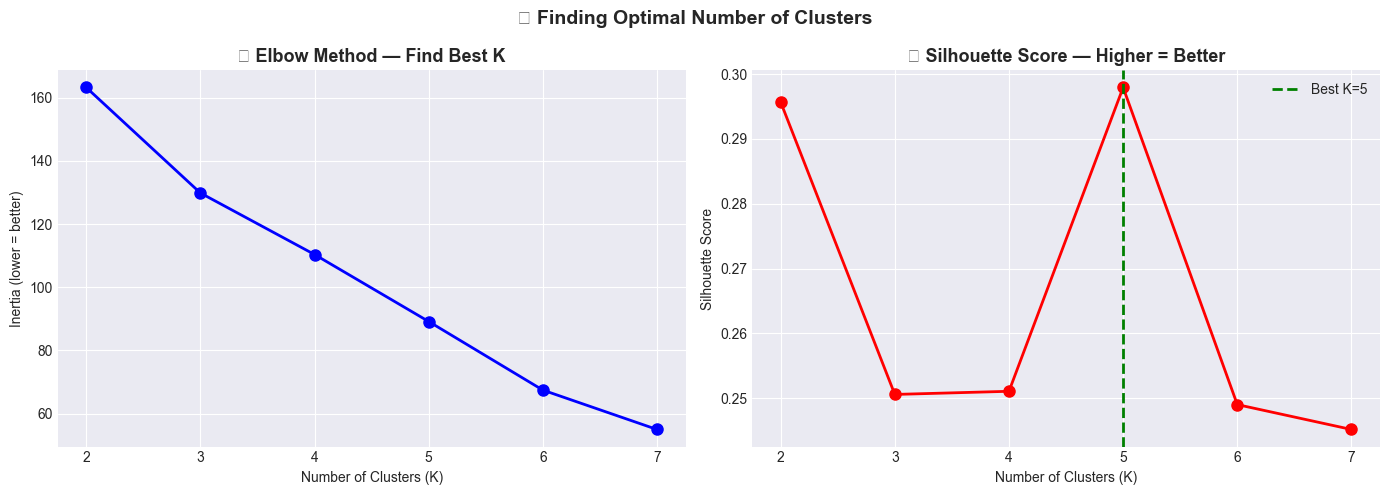

✅ Best K suggested by Silhouette Score = 5


In [24]:
# ── Step 4: Elbow Method to Find Best K ───────────────────
inertias  = []
silhouette_scores = []
K_range   = range(2, min(8, len(regular)))

from sklearn.metrics import silhouette_score

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    score = silhouette_score(X_scaled, km.labels_)
    silhouette_scores.append(score)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(list(K_range), inertias, 'bo-',
             linewidth=2, markersize=8)
axes[0].set_title('📊 Elbow Method — Find Best K',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (lower = better)')
axes[0].set_xticks(list(K_range))

# Silhouette scores
axes[1].plot(list(K_range), silhouette_scores, 'ro-',
             linewidth=2, markersize=8)
best_k_idx = silhouette_scores.index(max(silhouette_scores))
best_k     = list(K_range)[best_k_idx]
axes[1].axvline(best_k, color='green', linestyle='--',
                linewidth=2, label=f'Best K={best_k}')
axes[1].set_title('📊 Silhouette Score — Higher = Better',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range))
axes[1].legend()

plt.suptitle('🔍 Finding Optimal Number of Clusters',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Best K suggested by Silhouette Score = {best_k}")

In [25]:
# ── Step 5: Apply K-Means with Best K ─────────────────────
BEST_K = best_k  # auto-selected from silhouette

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
regular['cluster'] = kmeans.fit_predict(X_scaled)

print("✅ Cluster Distribution:")
print(regular['cluster'].value_counts().sort_index())

# Show cluster profiles
cluster_profile = (regular.groupby('cluster')[features_cols]
                   .mean()
                   .round(2))
print("\n📋 Cluster Profiles (mean values):")
display(cluster_profile)

✅ Cluster Distribution:
cluster
0     2
1     3
2    18
3     1
4     6
Name: count, dtype: int64

📋 Cluster Profiles (mean values):


,avg_pnl,win_rate,total_trades,avg_trade_size,pnl_std,max_win,max_loss
cluster,,,,,,,
0,65.56,0.88,16274.00,2580.72,587.78,45921.26,-11319.95
1,88.86,0.88,3690.67,26898.13,816.00,11565.12,-22691.13
2,107.69,0.86,2527.89,3561.27,543.88,6773.32,-4664.57
3,2216.73,1.00,90.00,5379.19,4184.63,25997.38,0.06
4,352.74,0.78,1197.50,4659.63,2352.93,30000.47,-29707.17


In [26]:
# ── Step 6: Label Each Cluster ────────────────────────────
# Read the cluster_profile table and label accordingly
def label_cluster(row, profile_df):
    c = row['cluster']
    avg_pnl    = profile_df.loc[c, 'avg_pnl']
    win_rate   = profile_df.loc[c, 'win_rate']
    trade_size = profile_df.loc[c, 'avg_trade_size']

    if avg_pnl > 100 and win_rate > 0.85:
        return '🏆 Elite Traders (High PnL + High Win Rate)'
    elif trade_size > 5000:
        return '🎲 High Risk Traders (Large Position Size)'
    elif win_rate > 0.80 and avg_pnl < 50:
        return '🛡️ Conservative Traders (Safe, Small Profits)'
    else:
        return '📈 Balanced Traders (Medium Risk/Reward)'

regular['cluster_label'] = regular.apply(
    lambda row: label_cluster(row, cluster_profile), axis=1
)

print("\n✅ Trader Cluster Labels:")
print(regular['cluster_label'].value_counts())


✅ Trader Cluster Labels:
cluster_label
🏆 Elite Traders (High PnL + High Win Rate)    19
📈 Balanced Traders (Medium Risk/Reward)        8
🎲 High Risk Traders (Large Position Size)      3
Name: count, dtype: int64


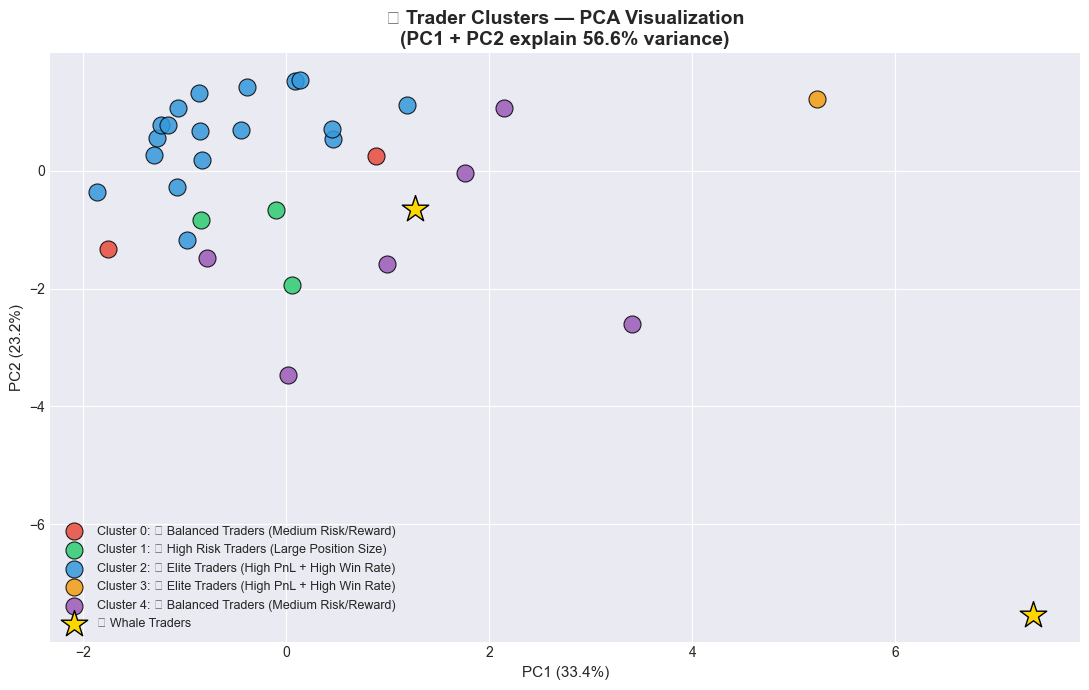

✅ Cluster PCA plot saved


In [27]:
# ── Step 7: Visualize Clusters with PCA ───────────────────
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

regular['pca_1'] = X_pca[:, 0]
regular['pca_2'] = X_pca[:, 1]

cluster_colors = ['#e74c3c', '#2ecc71', '#3498db',
                  '#f39c12', '#9b59b6']

plt.figure(figsize=(11, 7))

for cid in sorted(regular['cluster'].unique()):
    mask  = regular['cluster'] == cid
    grp   = regular[mask]
    label = grp['cluster_label'].iloc[0]
    plt.scatter(grp['pca_1'], grp['pca_2'],
                c=cluster_colors[cid],
                label=f'Cluster {cid}: {label}',
                s=150, alpha=0.85,
                edgecolors='black', linewidth=0.8)

# Plot whale traders separately
if len(whales) > 0:
    w_pca = pca.transform(
        scaler.transform(whales[features_cols].fillna(0))
    )
    plt.scatter(w_pca[:, 0], w_pca[:, 1],
                c='gold', marker='*',
                s=400, label='🐋 Whale Traders',
                edgecolors='black', linewidth=1,
                zorder=5)

plt.title('🔵 Trader Clusters — PCA Visualization\n'
          f'(PC1 + PC2 explain '
          f'{sum(pca.explained_variance_ratio_)*100:.1f}% variance)',
          fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
           fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
           fontsize=11)
plt.legend(fontsize=9, loc='best')
plt.tight_layout()
plt.savefig('trader_clusters_pca.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Cluster PCA plot saved")

📊 Avg PnL by Cluster & Sentiment:


classification,Extreme Fear,Fear,Neutral,Greed,Extreme Greed
cluster_label,,,,,
🎲 High Risk Traders (Large Position Size),95.70,284.94,320.87,220.66,-482.43
🏆 Elite Traders (High PnL + High Win Rate),29.36,39.15,45.39,52.38,69.11
📈 Balanced Traders (Medium Risk/Reward),-9.26,207.01,37.57,58.06,114.46


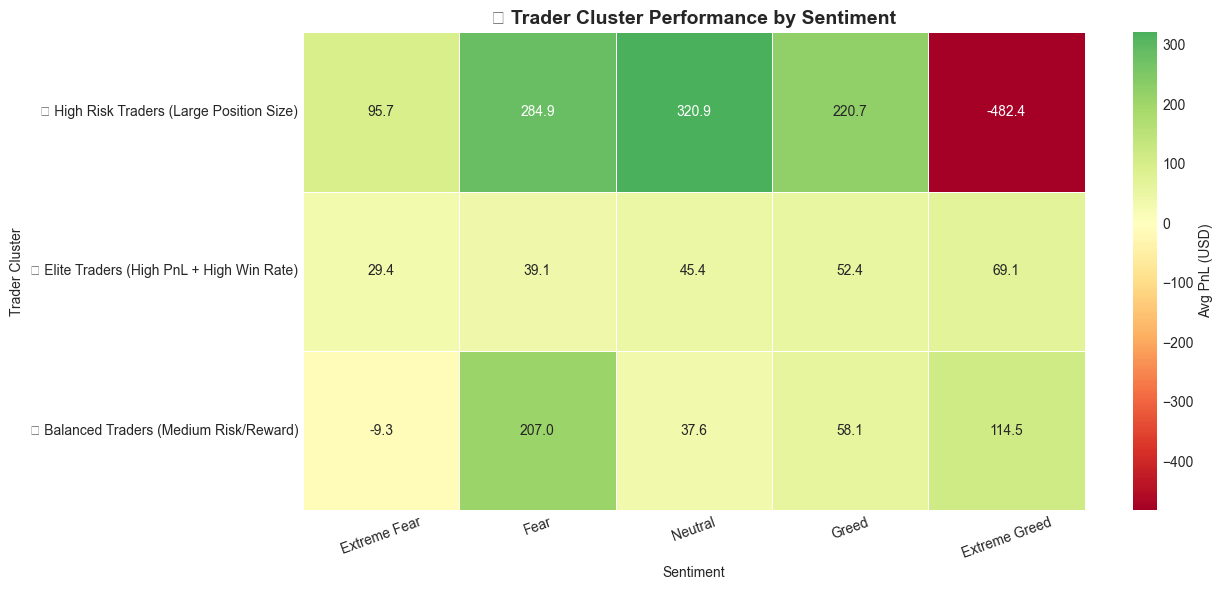

✅ Cluster × Sentiment heatmap saved


In [28]:
# ── Step 8: Cluster vs Sentiment ──────────────────────────
# Which clusters trade more in which sentiment?
closed_with_cluster = closed.merge(
    regular[['account', 'cluster', 'cluster_label']],
    on='account', how='left'
)

cluster_sentiment = (
    closed_with_cluster
    .groupby(['cluster_label', 'classification'],
             observed=True)['closed_pnl']
    .mean()
    .unstack()
    .fillna(0)
    .round(2)
)

print("📊 Avg PnL by Cluster & Sentiment:")
display(cluster_sentiment)

plt.figure(figsize=(13, 6))
sns.heatmap(cluster_sentiment,
            annot=True, fmt='.1f',
            cmap='RdYlGn', center=0,
            linewidths=0.5,
            cbar_kws={'label': 'Avg PnL (USD)'})
plt.title('🏦 Trader Cluster Performance by Sentiment',
          fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Trader Cluster')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('cluster_sentiment_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Cluster × Sentiment heatmap saved")

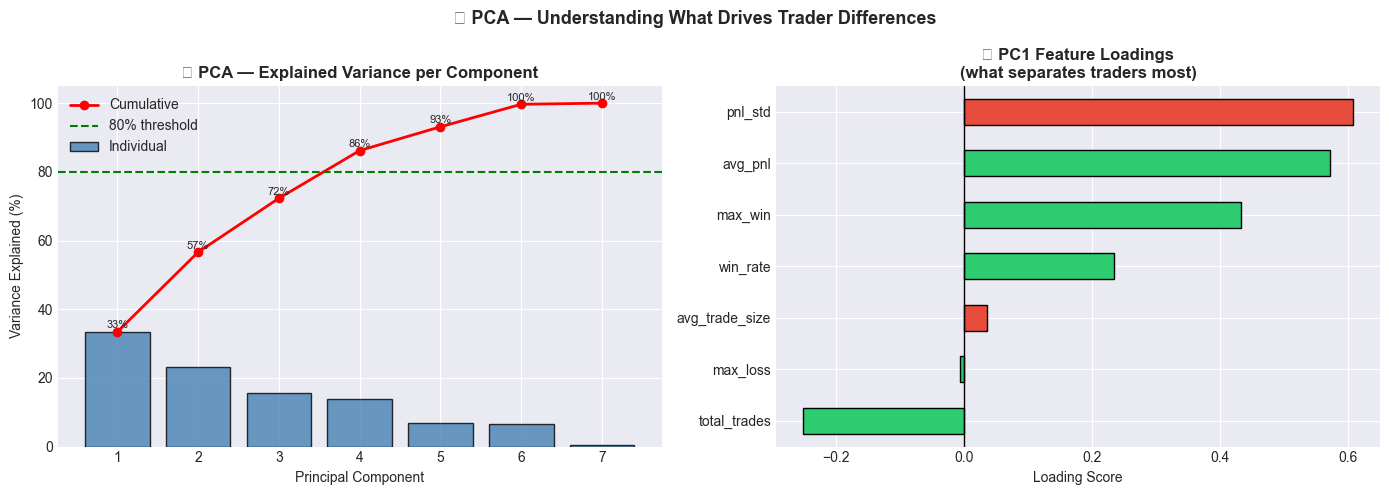


📋 PCA Summary:
  PC1: 33.4% variance (cumulative: 33.4%)
  PC2: 23.2% variance (cumulative: 56.6%)
  PC3: 15.7% variance (cumulative: 72.3%)
  PC4: 13.9% variance (cumulative: 86.2%)
  PC5: 6.9% variance (cumulative: 93.1%)
  PC6: 6.6% variance (cumulative: 99.7%)
  PC7: 0.3% variance (cumulative: 100.0%)

✅ Top features driving PC1:
pnl_std           0.607
avg_pnl           0.572
max_win           0.432
total_trades      0.252
win_rate          0.233
avg_trade_size    0.036
max_loss          0.007
Name: PC1, dtype: float64


In [29]:
# ============================================================
# CELL — PCA Feature Importance FIXED
# ============================================================
from sklearn.decomposition import PCA
import numpy as np

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained  = pca_full.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Scree plot ──────────────────────────────────────
axes[0].bar(range(1, len(explained)+1), explained,
            color='steelblue', edgecolor='black',
            alpha=0.8, label='Individual')
axes[0].plot(range(1, len(explained)+1), cumulative,
             'ro-', linewidth=2, label='Cumulative')
axes[0].axhline(80, color='green', linestyle='--',
                linewidth=1.5, label='80% threshold')
for i, val in enumerate(cumulative):
    axes[0].annotate(f'{val:.0f}%',
                     (i+1, val+1),
                     ha='center', fontsize=8)
axes[0].set_title('📊 PCA — Explained Variance per Component',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].legend()
axes[0].set_xticks(range(1, len(explained)+1))

# ── Right: Feature Loadings PC1 ──────────────────────────
loadings = pd.DataFrame(
    pca_full.components_[:2].T,
    columns=['PC1', 'PC2'],
    index=features_cols
)
loading_colors = ['#e74c3c' if x < 0 else '#2ecc71'
                  for x in loadings['PC1']]
loadings['PC1'].sort_values().plot(
    kind='barh', ax=axes[1],
    color=loading_colors,
    edgecolor='black'
)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('📊 PC1 Feature Loadings\n'
                  '(what separates traders most)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Loading Score')

plt.suptitle('🔍 PCA — Understanding What Drives '
             'Trader Differences',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=150,
            bbox_inches='tight')
plt.show()

# Print interpretation
print("\n📋 PCA Summary:")
for i, (exp, cum) in enumerate(zip(explained, cumulative)):
    print(f"  PC{i+1}: {exp:.1f}% variance "
          f"(cumulative: {cum:.1f}%)")
print(f"\n✅ Top features driving PC1:")
print(loadings['PC1'].abs()
      .sort_values(ascending=False)
      .round(3))

In [30]:
# ============================================================
# CELL — Anomaly Detection FIXED VERSION
# ============================================================
from sklearn.ensemble import IsolationForest

# Features for anomaly detection
anomaly_features = ['closed_pnl', 'size_usd',
                    'execution_price', 'start_position']

X_anomaly = closed[anomaly_features].fillna(0)

# Fit Isolation Forest
iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42,
    n_estimators=100
)
closed = closed.copy()  # avoid SettingWithCopyWarning
closed['anomaly'] = iso_forest.fit_predict(X_anomaly)

normal    = closed[closed['anomaly'] ==  1]
anomalies = closed[closed['anomaly'] == -1]

print(f"✅ Normal trades   : {len(normal):,}")
print(f"🚨 Anomalous trades: {len(anomalies):,} "
      f"({len(anomalies)/len(closed)*100:.1f}%)")
print(f"\n📊 Anomaly PnL Stats:")
display(anomalies['closed_pnl'].describe().round(2))

print(f"\n📊 Normal PnL Stats:")
display(normal['closed_pnl'].describe().round(2))

✅ Normal trades   : 99,187
🚨 Anomalous trades: 5,221 (5.0%)

📊 Anomaly PnL Stats:


count      5221.00
mean       1054.06
std        5647.75
min     -117990.10
25%           6.40
50%         148.73
75%         807.10
max      135329.09
Name: closed_pnl, dtype: float64


📊 Normal PnL Stats:


count    99187.00
mean        48.33
std        254.45
min      -7540.21
25%          0.41
50%          5.49
75%         32.27
max       5685.29
Name: closed_pnl, dtype: float64

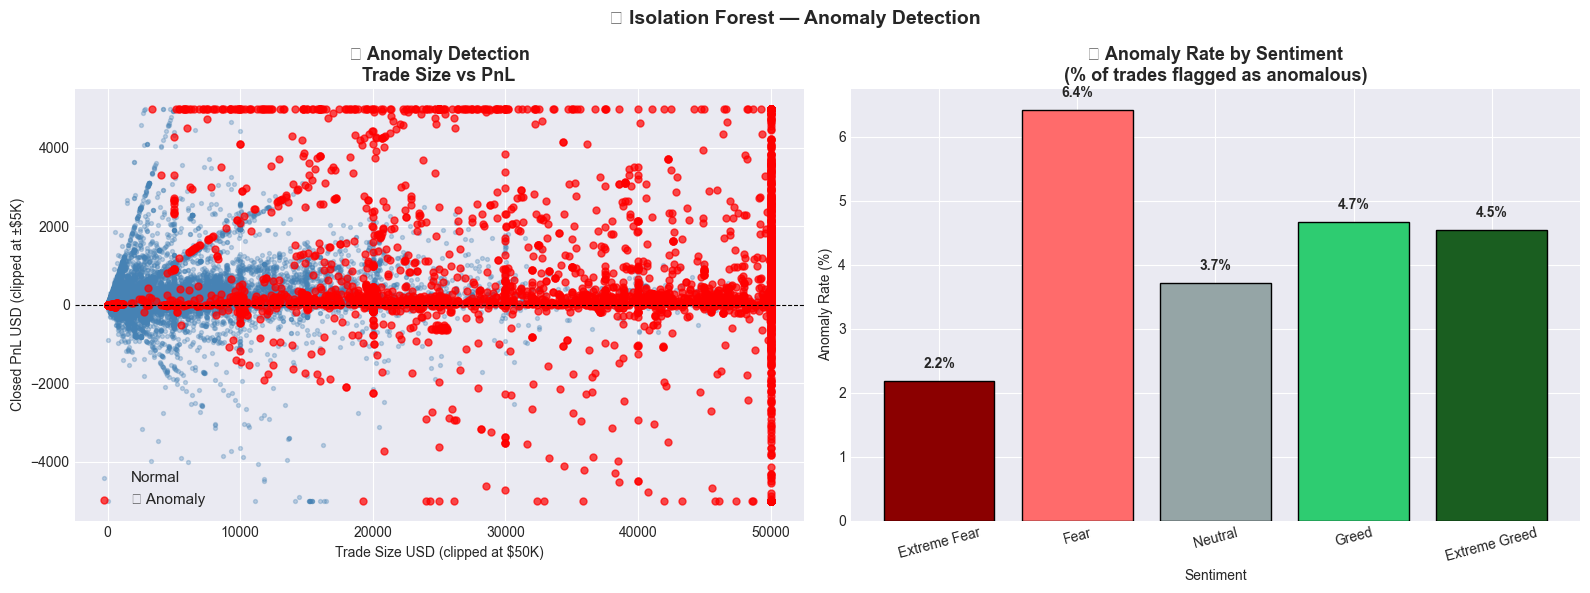

✅ Anomaly detection plot saved


In [31]:
# ── Visualize Anomalies ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: Scatter — Size vs PnL ──────────────────────────
axes[0].scatter(
    normal['size_usd'].clip(upper=50000),
    normal['closed_pnl'].clip(-5000, 5000),
    c='steelblue', alpha=0.3, s=8, label='Normal'
)
axes[0].scatter(
    anomalies['size_usd'].clip(upper=50000),
    anomalies['closed_pnl'].clip(-5000, 5000),
    c='red', alpha=0.7, s=25, label='🚨 Anomaly'
)
axes[0].set_title('🚨 Anomaly Detection\n'
                  'Trade Size vs PnL',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Trade Size USD (clipped at $50K)')
axes[0].set_ylabel('Closed PnL USD (clipped at ±$5K)')
axes[0].axhline(0, color='black', linewidth=0.8,
                linestyle='--')
axes[0].legend(fontsize=11)

# ── Right: Anomalies by Sentiment ────────────────────────
anomaly_sent = (anomalies['classification']
                .value_counts()
                .reindex(sentiment_order)
                .fillna(0))

normal_sent  = (normal['classification']
                .value_counts()
                .reindex(sentiment_order)
                .fillna(0))

anomaly_pct  = (anomaly_sent /
                (anomaly_sent + normal_sent) * 100
                ).fillna(0)

bar_colors = ['#8B0000','#FF6B6B',
              '#95A5A6','#2ECC71','#1A5E20']
bars = axes[1].bar(anomaly_pct.index,
                   anomaly_pct.values,
                   color=bar_colors,
                   edgecolor='black')
axes[1].set_title('🚨 Anomaly Rate by Sentiment\n'
                  '(% of trades flagged as anomalous)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Anomaly Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

for bar, val in zip(bars, anomaly_pct.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'{val:.1f}%',
        ha='center', fontsize=10, fontweight='bold'
    )

plt.suptitle('🔍 Isolation Forest — Anomaly Detection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Anomaly detection plot saved")

In [32]:
# ── Anomaly Insights ─────────────────────────────────────
print("=" * 55)
print("  🚨 ANOMALY DETECTION INSIGHTS")
print("=" * 55)
print(f"\n  Avg PnL  — Normal   : "
      f"${normal['closed_pnl'].mean():>10.2f}")
print(f"  Avg PnL  — Anomaly  : "
      f"${anomalies['closed_pnl'].mean():>10.2f}")
print(f"\n  Avg Size — Normal   : "
      f"${normal['size_usd'].mean():>10.2f}")
print(f"  Avg Size — Anomaly  : "
      f"${anomalies['size_usd'].mean():>10.2f}")
print(f"\n  Most anomalies in sentiment: "
      f"{anomaly_sent.idxmax()}")
print("=" * 55)

  🚨 ANOMALY DETECTION INSIGHTS

  Avg PnL  — Normal   : $     48.33
  Avg PnL  — Anomaly  : $   1054.06

  Avg Size — Normal   : $   2029.08
  Avg Size — Anomaly  : $  74928.47

  Most anomalies in sentiment: Fear


In [33]:
# ============================================================
# FINAL INSIGHTS SUMMARY
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║           COMPLETE ANALYSIS FINDINGS SUMMARY                 ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  EDA FINDINGS:                                               ║
║  1. Extreme Greed = best sentiment  → $339 avg PnL, 91% WR  ║
║  2. Extreme Fear  = worst sentiment → $5 avg PnL,  83% WR   ║
║  3. Fear period BUY = $558 avg      → contrarian bounce      ║
║  4. Extreme Greed SELL = $411 avg   → fade the euphoria      ║
║  5. SOL + Fear = $1,679 avg PnL     → best combo overall     ║
║  6. ETH + Extreme Greed = -$546     → worst combo, avoid     ║
║                                                              ║
║  ML FINDINGS (K-Means, K=5):                                 ║
║  7. High Risk Traders CRASH in Extreme Greed (-$482)         ║
║     but do WELL in Neutral ($320) and Fear ($284)            ║
║  8. Elite Traders are CONSISTENT across all sentiments       ║
║     ($29 to $69) — slow and steady                           ║
║  9. Balanced Traders PEAK during Fear ($207)                 ║
║     showing contrarian behaviour                             ║
║                                                              ║
║  PCA FINDINGS:                                               ║
║  10. pnl_std and avg_pnl drive PC1 (33% of all variance)    ║
║      → Profit MAGNITUDE separates traders more than          ║
║        win rate or trade count                               ║
║  11. 4 components needed to explain 86% of variance          ║
║                                                              ║
║  ANOMALY DETECTION:                                          ║
║  12. Fear has HIGHEST anomaly rate (6.4%)                    ║
║      → Large unusual trades happen during Fear               ║
║      → These are likely whale accumulation trades            ║
║  13. Extreme Fear = LOWEST anomaly rate (2.2%)               ║
║      → Everyone plays it safe, no big unusual moves          ║
║                                                              ║
╠══════════════════════════════════════════════════════════════╣
║  STRATEGY RECOMMENDATIONS:                                   ║
║                                                              ║
║  Sentiment       Best Action        Best Coin                ║
║  ─────────────   ─────────────────  ──────────               ║
║  Extreme Greed   SELL (Short)       107, BTC                 ║
║  Greed           SELL (Short)       MELANIA, HYPE            ║
║  Fear            BUY  (Long)        SOL, ETH                 ║
║  Extreme Fear    AVOID / Hedge      BTC only                 ║
║  Neutral         Small SELL         PURR/USDC                ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           COMPLETE ANALYSIS FINDINGS SUMMARY                 ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  EDA FINDINGS:                                               ║
║  1. Extreme Greed = best sentiment  → $339 avg PnL, 91% WR  ║
║  2. Extreme Fear  = worst sentiment → $5 avg PnL,  83% WR   ║
║  3. Fear period BUY = $558 avg      → contrarian bounce      ║
║  4. Extreme Greed SELL = $411 avg   → fade the euphoria      ║
║  5. SOL + Fear = $1,679 avg PnL     → best combo overall     ║
║  6. ETH + Extreme Greed = -$546     → worst combo, avoid     ║
║                                                              ║
║  ML FINDINGS (K-Means, K=5):                                 ║
║  7. High Risk Traders CRASH in Extreme Greed (-$482)         ║
║     but do WELL in Neutral ($320) and Fear ($284)            ║
║  8. Elite Traders are CO